### Import all required libraries

In [ ]:
# Import libraries
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Get the randomness, ensure consistant random distribution
SEED = 42
np.random.seed(SEED)

### Training and testing data preprocessing is done together

### Load dataset (training and testing data)

In [ ]:
# Load training dataset
train_df = pd.read_csv("customer_churn_dataset-training-master.csv")

print(train_df)

        CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0              2.0  30.0  Female    39.0             14.0            5.0   
1              3.0  65.0  Female    49.0              1.0           10.0   
2              4.0  55.0  Female    14.0              4.0            6.0   
3              5.0  58.0    Male    38.0             21.0            7.0   
4              6.0  23.0    Male    32.0             20.0            5.0   
...            ...   ...     ...     ...              ...            ...   
440828    449995.0  42.0    Male    54.0             15.0            1.0   
440829    449996.0  25.0  Female     8.0             13.0            1.0   
440830    449997.0  26.0    Male    35.0             27.0            1.0   
440831    449998.0  28.0    Male    55.0             14.0            2.0   
440832    449999.0  31.0    Male    48.0             20.0            1.0   

        Payment Delay Subscription Type Contract Length  Total Spend  \
0              

In [ ]:
# Load testing dataset
test_df = pd.read_csv("customer_churn_dataset-testing-master.csv")

print(test_df)

       CustomerID  Age  Gender  Tenure  Usage Frequency  Support Calls  \
0               1   22  Female      25               14              4   
1               2   41  Female      28               28              7   
2               3   47    Male      27               10              2   
3               4   35    Male       9               12              5   
4               5   53  Female      58               24              9   
...           ...  ...     ...     ...              ...            ...   
64369       64370   45  Female      33               12              6   
64370       64371   37    Male       6                1              5   
64371       64372   25    Male      39               14              8   
64372       64373   50  Female      18               19              7   
64373       64374   52  Female      45               15              9   

       Payment Delay Subscription Type Contract Length  Total Spend  \
0                 27             Basic  

In [ ]:
train_df.head(15)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
5,8.0,51.0,Male,33.0,25.0,9.0,26.0,Premium,Annual,129.0,8.0,1.0
6,9.0,58.0,Female,49.0,12.0,3.0,16.0,Standard,Quarterly,821.0,24.0,1.0
7,10.0,55.0,Female,37.0,8.0,4.0,15.0,Premium,Annual,445.0,30.0,1.0
8,11.0,39.0,Male,12.0,5.0,7.0,4.0,Standard,Quarterly,969.0,13.0,1.0
9,12.0,64.0,Female,3.0,25.0,2.0,11.0,Standard,Quarterly,415.0,29.0,1.0


In [ ]:
test_df.head(15)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0
5,6,30,Male,41,14,10,10,Premium,Monthly,500,29,0
6,7,47,Female,37,15,9,28,Basic,Quarterly,574,14,1
7,8,54,Female,36,11,0,18,Standard,Monthly,323,16,0
8,9,36,Male,20,5,10,8,Basic,Monthly,687,8,0
9,10,65,Male,8,4,2,23,Basic,Annual,995,10,0


Explanation:  
Use head() to show the data row-by-row. Number inside head() is the number of line we need.

### Data label distribution

In [ ]:
# Check the label distributions
train_df_label_distribution = train_df['Churn'].value_counts()
print(train_df_label_distribution)

test_df_label_distribution = test_df['Churn'].value_counts()
print(test_df_label_distribution)

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64
Churn
0    33881
1    30493
Name: count, dtype: int64


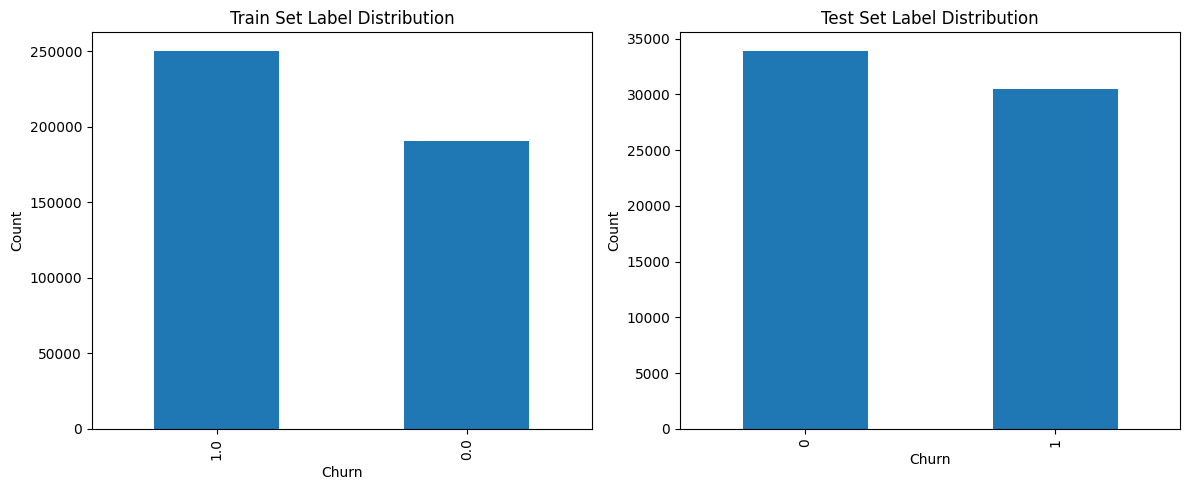

In [ ]:
# Plot train distribution
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
train_df['Churn'].value_counts().plot(kind='bar')
plt.title("Train Set Label Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

# Plot test distribution
plt.subplot(1,2,2)
test_df['Churn'].value_counts().plot(kind='bar')
plt.title("Test Set Label Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


As we can see the data in training and testing datasets are imbalance of class labels, hence we decide to combine the datasets and split the datasets (stratification) to preserve class distribution.

### Merge training and testing dataset

In [ ]:
# Merge train and test CSVs into one dataset
df_all = pd.concat([train_df, test_df], axis=0)


In [ ]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 505207 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  object 
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  object 
 8   Contract Length    505206 non-null  object 
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), object(3)
memory usage: 50.1+ MB


Explanation:  
info() shows us the attribute lists with its corresponding data types.

### Identify the missing values for training data

In [ ]:
# Check missing values per column
missing_values = df_all.isnull().sum()

# Print the missing values if it is available
print(missing_values)

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64


Explanation:  
== The code ==  
Find the missing values by using isnull() in df_all, sum() to accumulate the number of value.  

== The outcome ==  
This shows how many missing values each attribute has. It will show a list of attributes with their missing values respectively.

### Propose a method to clean the missing values.

In [ ]:
# Fill numerical columns with median
# Choose the numerical columns from training data
num_cols = df_all.select_dtypes(include="number").columns
# Fill in the columns with median
df_all[num_cols] = df_all[num_cols].fillna(df_all[num_cols].median())

# Fill categorical columns with mode
# Choose the categorical columns from training data
cat_cols = df_all.select_dtypes(include="object").columns
# Fill in the columns with mode
for col in cat_cols:
  df_all[col].fillna(df_all[col].mode()[0], inplace=True)

/tmp/ipython-input-863125974.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_all[col].fillna(df_all[col].mode()[0], inplace=True)


Explanation:  
== The code ==  
num_cols = df_all.select_dtypes(include="number").columns means:  
from df_all, select numerical columns, and define it as num_cols.  

df_all[num_cols] = df_all[num_cols].fillna(df_all[num_cols].median())  
For each key (numerical column) in df_all, fillna means replaces NaN values, .median() means replace the missing columns with median, but all non-missing values remain unchanged.  

cat_cols = df_all.select_dtypes(include="object").columns means:  
from df_all, select categorical columns, and define it as cat_cols.  

for col in cat_cols:  
df_all[col].fillna(df_all[col].mode()[0], inplace=True)  
for each columns, fill up those NaN columns with mode().  

We use median for numerical columns as it is robust to outliers, while mode preserves categorical meaning. Thus, we can continue to train our model with the training data instead of delete them. This approach helps preserve dataset size while minimizing distortion to the original data distribution.    


### Check for missing data after data cleaning.

In [ ]:
# Check missing values per column
missing_values = df_all.isnull().sum()

# Print the missing values if it is available
print(missing_values)

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


Explanation:  
== The code ==  
Find the missing values by using isnull() in df_all data, sum() to accumulate the number of value.  

== The outcome ==  
This shows how many missing values each attribute has. It will show a list of attributes with their missing values respectively. Since our result shows 0 for all attributes, there is no missing value.

### (1) Use one-hot encoding to transform the non-class categorical features into numbers.

In [ ]:
# Separate training features and target
# Drop target and CustomerID column
X = df_all.drop(columns=["Churn", "CustomerID"])
y = df_all["Churn"]

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, drop_first=False)


Explanation:  
One-hot encoding is used to convert categorical variables into a format that can be readily used by machine learning algorithms. The basic idea of one-hot encoding is to create new variables that take on values 0 and 1 to represent the original categorical values. It is often useful to transform categorical features into vectors.  

== The code ==  
We define X by getting all column in df_all but dropping "CustomerID" and "Churn". "CustomerID" is just an identifier and it is not predictive to our classification task but might make confusion and affect the accuracy, "Churn" is dropped as a target column to avoid it mixed with the training features.  
We define y to preserve a "correct answer" to make comparison and calculate accuracy with the predicted result after training the model.  
X_encoded is got by transforming the non-class categorical features into numbers. Although the numerical columns also included in the X to be encoded, but one-hot encoder can identify and just encode the categorical columns, the numerical columns remain unchanged.  

### Stratification

In [ ]:
# Stratified split: ensures same class balance in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.4,
    random_state=SEED,
    stratify=y
)


Explanation:  
We do stratification to split the training and testing datasets by using train_test_split(). Training 60% and testing 40%. We use X and y defined before. X is the feature with cleaned data, y is the correct label. We use random_state=SEED to do randomness and stratify=y to preserve class proportions. It is not used to balance the dataset.  
     

In [ ]:
# Check if the columns had been dropped correctly in training dataset
X_train.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Female,Gender_Male,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly
351363,47.0,10.0,28.0,3.0,1.0,548.11,18.0,False,True,False,True,False,True,False,False
89762,51.0,20.0,13.0,4.0,13.0,302.00,21.0,False,True,False,True,False,True,False,False
250579,57.0,41.0,18.0,7.0,4.0,933.14,19.0,True,False,True,False,False,True,False,False
393413,47.0,14.0,15.0,0.0,13.0,853.20,3.0,True,False,True,False,False,True,False,False
362425,45.0,49.0,2.0,0.0,9.0,626.91,13.0,False,True,True,False,False,True,False,False


In [ ]:
# Check if the columns had been dropped correctly in testing dataset
X_test.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Female,Gender_Male,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly
205918,39.0,35.0,20.0,9.0,18.0,407.76,12.0,True,False,False,False,True,True,False,False
206385,44.0,46.0,13.0,0.0,17.0,131.71,16.0,True,False,False,False,True,True,False,False
18629,33.0,12.0,8.0,4.0,20.0,588.00,17.0,False,True,False,False,True,False,True,False
42755,61.0,51.0,17.0,6.0,12.0,771.00,16.0,False,True,True,False,False,False,False,True
22559,64.0,7.0,7.0,7.0,14.0,408.00,23.0,True,False,False,False,True,False,True,False


From the head() above, we can observe that "CustomerID" and "Churn" is dropped successfully. Besides, the categorical columns are encoded. Although the columns show True and False, but True means 1 and False represents 0, so we had transformed it into numbers.

### (2) The Naïve Bayes API must be from Scikit-Learn. But you can use Numpy, Pandas and other non-ML libraries for preprocessing and visualisation purposes.

In [ ]:
# Fit the model
nb_model = GaussianNB()

# Define StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform stratified cross-validation
scores = cross_val_score(
    nb_model,
    X_train,
    y_train,
    cv=skf,
    scoring='f1')  # f1 is better for imbalanced data

print("F1 scores for each fold:", scores)
print("Mean F1 score:", np.mean(scores))

# Fit on training data
nb_model.fit(X_train, y_train)

# Predict the train data to visualise the predictions
y_train_pred = nb_model.predict(X_train)

# Predict the testing data with trained data
y_pred = nb_model.predict(X_test)

F1 scores for each fold: [0.86220179 0.86424771 0.86461457 0.86304412 0.86399975]
Mean F1 score: 0.863621588180586


Explanation:  
In this task, GaussianNB is chosen. It is because GaussianNB assumes features are continuous and normally distributed. It is suitable for the numerical attributes like Age, Tenure, Payment Delay, etc in this task. For those categorical columns, GaussianNB can handle them together after they are one-hot encoded because the categorical features become 0 and 1, and GaussianNB treats them as valid numeric input like other numerical columns.
For BernoulliNB, it assumes features are binary (true and false), so it is best for text presense/absence or strictly categorical yes/no features. However, the most columns in our dataset are continuous values.   
For MultinomialNB, it assumes features are discrete or classification data that are counts or frequencies. Thus it is best for word counts in text classification or event frequencies. However, the columns that are one-hot encoded do not represent counts.  

== The code ==  
Firstly, we import GaussianNB from Scikit-Learn library. Then, we define a model using GaussianNB. Then we define StratifiedKFold() to do Stratification while doing K-fold for the training dataset as the data is imbalance. cross_val_score() is used to fit the StratifiedKFold() with X_train, y_train and scored by f1-score as f1-score show a balance value of precision and recall, gives a fairer calculation for imbalanced model. Next, we fit the model with our cleaned and encoded training data X_train and give it the correct answer y_train for their learning purpose. After learning, we can use predict() to predict the X_train and X_test to do the predictions and classifications to get the classification result.  

#### Evaluate the model performance

Accuracy: 0.8553960501378146 (85.54 %)

Classification Report: 
               precision    recall  f1-score   support

         0.0       0.80      0.89      0.85     89886
         1.0       0.91      0.83      0.86    112197

    accuracy                           0.86    202083
   macro avg       0.85      0.86      0.85    202083
weighted avg       0.86      0.86      0.86    202083



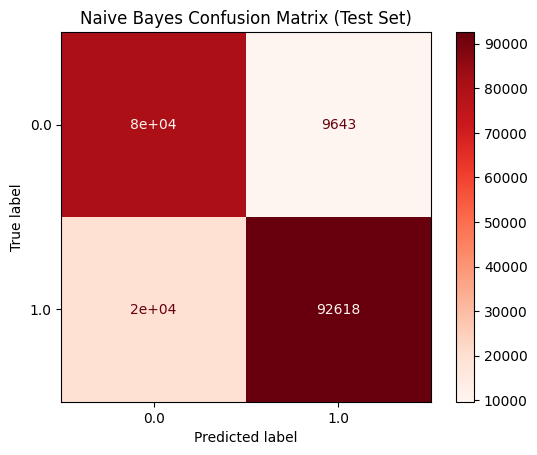

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print out the performance
print(f"Accuracy: {accuracy} ({accuracy * 100:.2f} %)")
print("\nClassification Report: \n", classification_report(y_test, y_pred))

# Define a confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Define class names based on unique values in y_test
class_names = [str(x) for x in sorted(y_test.unique())]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Reds")
plt.title("Naive Bayes Confusion Matrix (Test Set)")
plt.show()

Explanation:  
== The code ==  
After predictions, we can get the model accuracy by compare the predicted result (y_pred) with the true result (y_test). With the accuracy_score function, we can get our accuracy. Classification report and confusion matrix also be done for visualisation.  

== The outcome ==  
We can find that we get an accuracy of 0.86. Precision of 0.85, recall of 0.86 and F1-Score of 0.85 (at the macro avg).  
From the confusion matrix, the data at the diagonal (0 predicted as 0 and 1 predicted as 1) is correct, meaning that most of the data are predicted correctly. However, we can notice that 1 value always predicted as 0, with a counted value of 2.0 x 10 ^4, this is a False Negative (FN). The model is significantly better at identifying Churn (1.0) than identifying Non-Churn (0.0), which record a value of 92618 (TP). True Negative (TN) has a value 8 x 10 ^4, approximately 80 000 data. Lastly, the False Positive (FP) has a record of 9643 data.  

In [ ]:
# For first 15 results
for i in range(15):
  # Access actual label from train_label Series and predicted label from train_df
    print(f"Actual: {y_train.iloc[i]} | Predicted: {y_train_pred[i]}")

Actual: 0.0 | Predicted: 0.0
Actual: 1.0 | Predicted: 1.0
Actual: 1.0 | Predicted: 1.0
Actual: 0.0 | Predicted: 0.0
Actual: 0.0 | Predicted: 0.0
Actual: 1.0 | Predicted: 1.0
Actual: 0.0 | Predicted: 0.0
Actual: 0.0 | Predicted: 0.0
Actual: 1.0 | Predicted: 0.0
Actual: 1.0 | Predicted: 1.0
Actual: 0.0 | Predicted: 0.0
Actual: 0.0 | Predicted: 0.0
Actual: 0.0 | Predicted: 1.0
Actual: 0.0 | Predicted: 0.0
Actual: 0.0 | Predicted: 0.0


Explanation:  
Visualise the train dataset prediction result, we get a 13/15 correctness.

In [ ]:
# For first 15 results
for i in range(15):
  # Access actual label from test_label Series and predicted label from test_df
    print(f"Actual: {y_test.iloc[i]} | Predicted: {y_pred[i]}")

Actual: 1.0 | Predicted: 1.0
Actual: 1.0 | Predicted: 1.0
Actual: 1.0 | Predicted: 1.0
Actual: 0.0 | Predicted: 1.0
Actual: 0.0 | Predicted: 1.0
Actual: 1.0 | Predicted: 1.0
Actual: 1.0 | Predicted: 1.0
Actual: 1.0 | Predicted: 1.0
Actual: 0.0 | Predicted: 1.0
Actual: 1.0 | Predicted: 1.0
Actual: 0.0 | Predicted: 0.0
Actual: 1.0 | Predicted: 1.0
Actual: 0.0 | Predicted: 0.0
Actual: 1.0 | Predicted: 1.0
Actual: 1.0 | Predicted: 1.0


Explanation:  
Visualise the test dataset prediction result, we get a 12/15 correctness, slightly lower than training dataset.